In [1]:
import os, sys
# nbconvert runs with cwd = notebooks/; the src modules (and this notebook's
# own path references below) assume the project root instead.
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
sys.path.insert(0, os.getcwd())

# 01 — Exploratory Data Analysis

Telco Customer Churn dataset: 7,043 customers, 21 columns, ~26.5% churn rate.

This notebook profiles the raw data, documents a real data-quality issue in `TotalCharges`, and produces five charts -- each with a written finding -- that become the evidence base for the rest of the project.

In [2]:
import sys
sys.path.insert(0, '..')
import pandas as pd
from src.data import load_raw, clean
from src import eda

pd.set_option('display.max_columns', 30)

## Profile the raw data

In [3]:
df_raw = load_raw('data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv')
print(df_raw.shape)
df_raw.dtypes

(7043, 21)


customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

In [4]:
df_raw.isna().sum().sum()  # pandas sees zero nulls -- the trap below is why

np.int64(0)

In [5]:
df_raw['Churn'].value_counts(normalize=True) * 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

**26.54% churn.** A model that predicts "stay" for every customer gets 73.5% accuracy while catching zero churners -- accuracy is not a usable metric on this dataset (see `02_modeling.ipynb`).

## The `TotalCharges` trap

`TotalCharges` loads as an `object` column, not numeric. `df.isna().sum()` reports zero missing values above because the missingness is hiding as **whitespace strings**, not `NaN`.

In [6]:
blank = df_raw[df_raw['TotalCharges'].str.strip() == '']
print(f"{len(blank)} rows with blank TotalCharges")
print("Their tenure values:", sorted(blank['tenure'].unique()))

11 rows with blank TotalCharges
Their tenure values: [np.int64(0)]


**Finding:** all 11 blank rows have `tenure == 0` -- these are brand-new customers who have not yet been billed. Their true `TotalCharges` is 0, not missing, so `src/data.py` imputes 0 rather than dropping the rows. Dropping them would have removed exactly the zero-tenure segment, which the tenure chart below shows is the highest-churn segment in the dataset -- the wrong rows to lose.

In [7]:
df = clean(df_raw)
assert df.isna().sum().sum() == 0
df.shape

(7043, 20)

## Chart 1 — Churn by contract type

In [8]:
rates_contract = eda.chart_contract(df)
rates_contract

Contract
Month-to-month    42.709677
One year          11.269518
Two year           2.831858
Name: Churn, dtype: float64

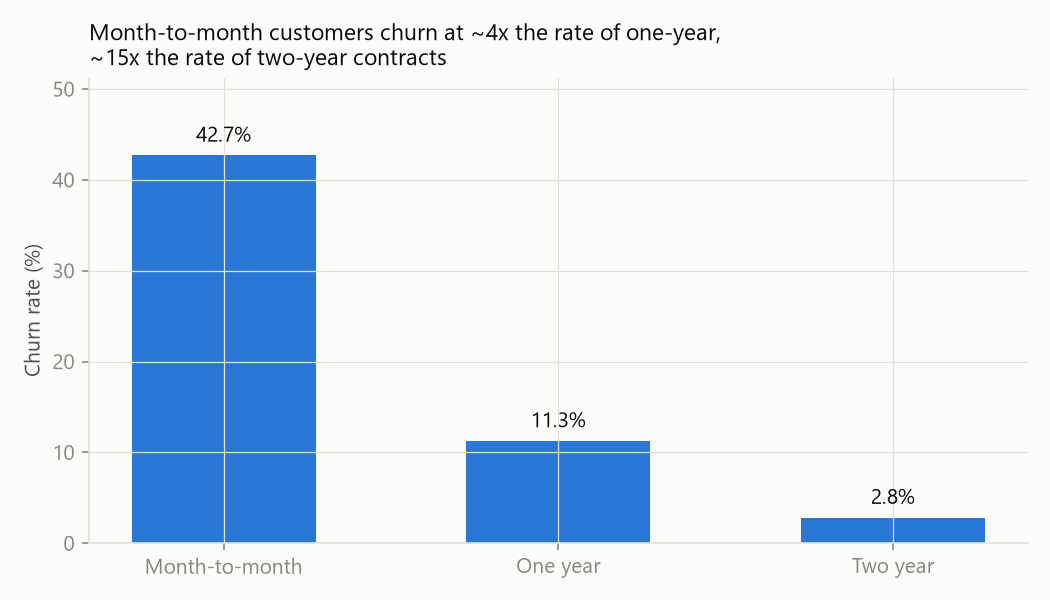

In [9]:
from IPython.display import Image
Image('reports/figures/churn_by_contract.png')

**Finding:** month-to-month customers churn at 42.7%, versus 11.3% for one-year and 2.8% for two-year contracts -- roughly 4x and 15x respectively. Contract type turns out to be the single strongest churn signal in the dataset (confirmed by SHAP in `03_explainability_and_threshold.ipynb`).

## Chart 2 — Churn by tenure bucket

In [10]:
rates_tenure = eda.chart_tenure(df)
rates_tenure

tenure_bucket
0-6mo      52.937205
7-12mo     35.886525
13-24mo    28.710938
25-48mo    20.388959
49-72mo     9.513176
Name: Churn, dtype: float64

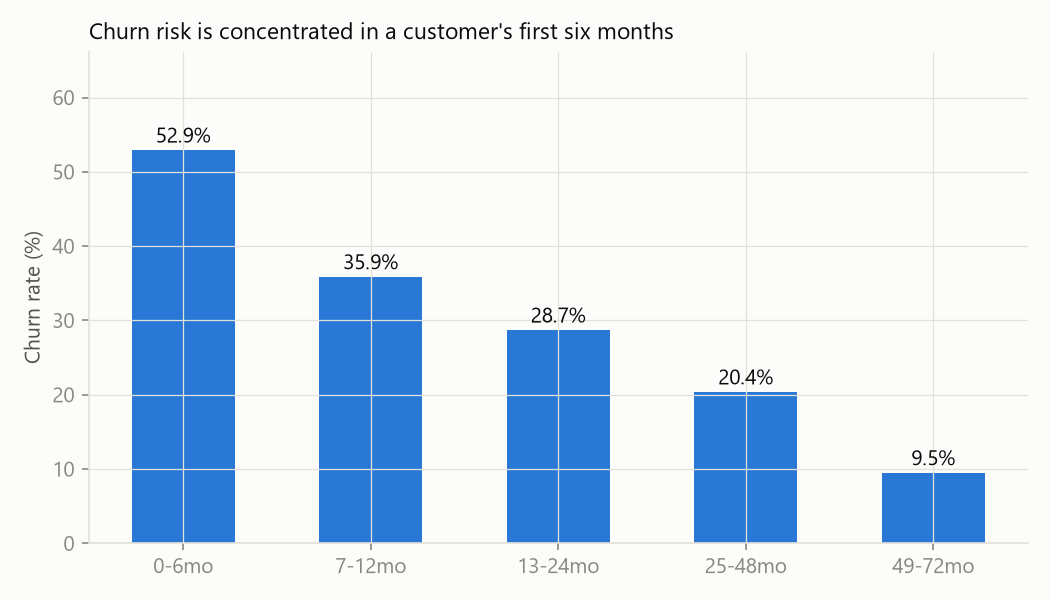

In [11]:
Image('reports/figures/churn_by_tenure.png')

**Finding:** churn falls almost monotonically with tenure, from 52.9% in the first six months to 9.5% after four years. Risk is front-loaded into onboarding -- retention spend is most efficient early, not spread evenly across the base.

## Chart 3 — Churn by internet service type

In [12]:
rates_internet = eda.chart_internet(df)
rates_internet

InternetService
Fiber optic    41.892765
DSL            18.959108
No              7.404980
Name: Churn, dtype: float64

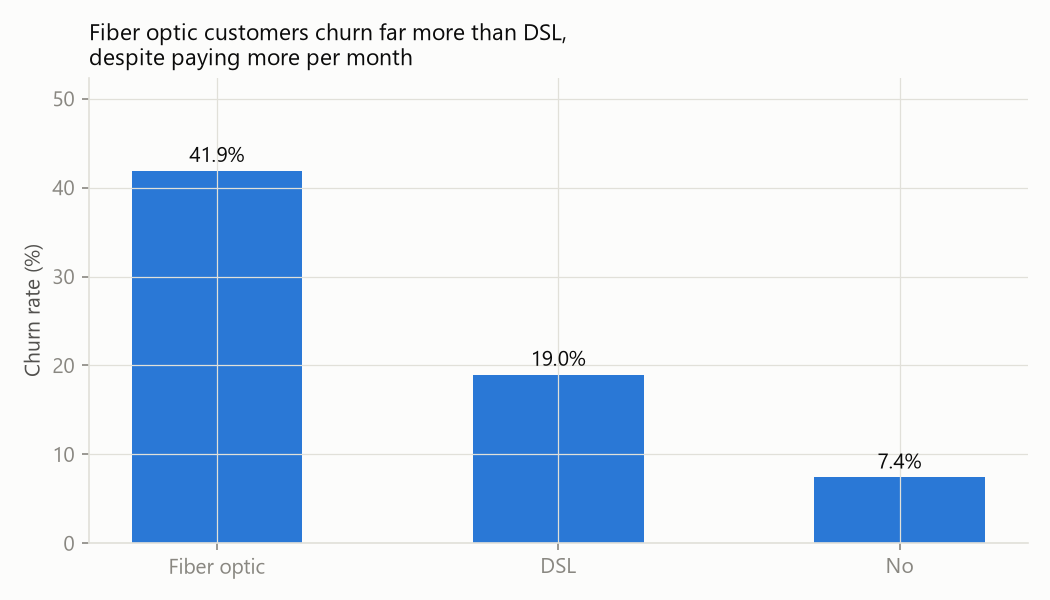

In [13]:
Image('reports/figures/churn_by_internet.png')

**Finding:** fiber optic customers churn at 41.9% versus 19.0% for DSL, despite fiber being the more expensive tier. This is the most counterintuitive finding in the dataset -- more expensive service should not correlate with *more* churn if price were the driver. It points at a service-quality or expectation-setting problem the churn model itself cannot diagnose (see Limitations in notebook 03).

## Chart 4 — Monthly charges distribution, by churn

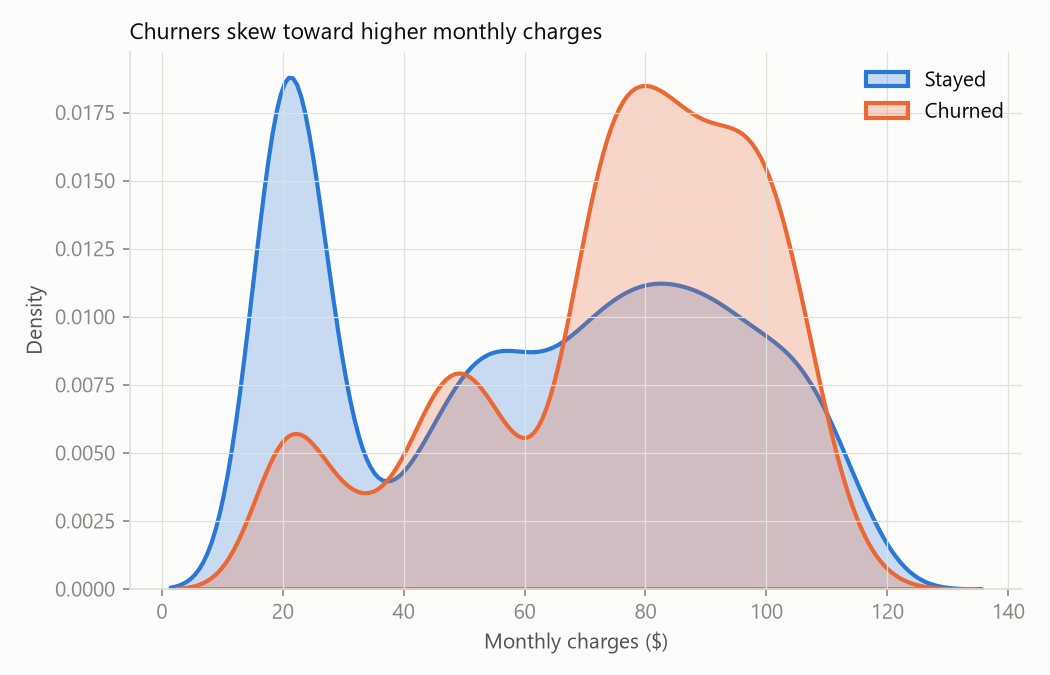

In [14]:
eda.chart_monthly_charges(df)
Image('reports/figures/monthly_charges_by_churn.png')

**Finding:** churners skew toward higher monthly charges, consistent with the fiber finding above -- but note this is a marginal, univariate view; SHAP dependence plots in notebook 03 isolate this effect while holding other features fixed.

## Chart 5 — Correlation heatmap

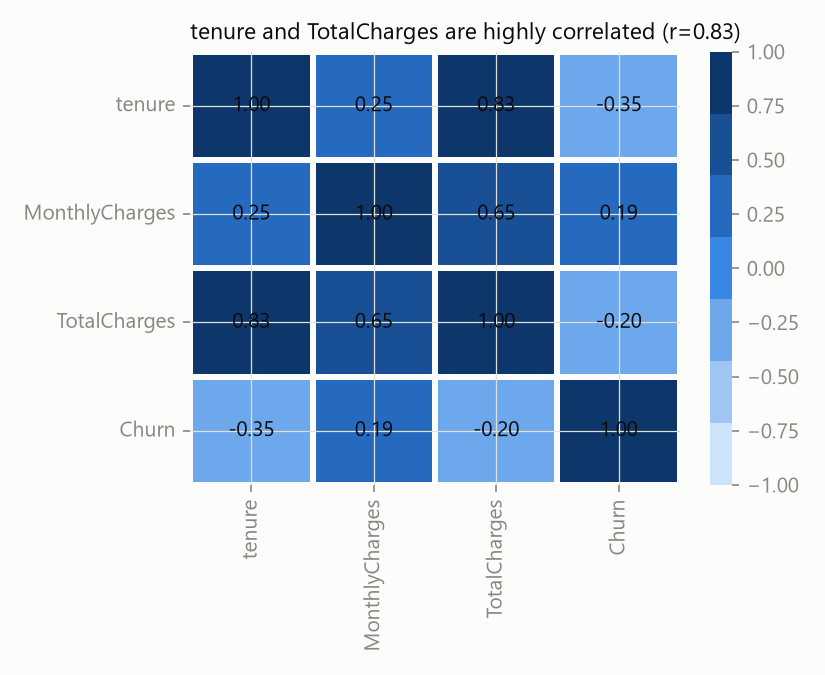

In [15]:
corr = eda.chart_correlation(df)
Image('reports/figures/correlation_heatmap.png')

**Finding:** `tenure` and `TotalCharges` are highly correlated (r=0.83), which makes sense -- `TotalCharges` is roughly `tenure x MonthlyCharges`. Both are kept as features: tree models (XGBoost) handle collinearity without issue, but this would need revisiting for a linear model that requires stable, interpretable coefficients.

## Summary

1. **Contract type dominates.** Month-to-month customers churn 4-15x more than term-contract customers.
2. **Risk concentrates in the first year**, then decays steadily.
3. **Fiber optic is an outlier** -- higher price, higher churn, likely a service-quality signal rather than a price signal.
4. **A data-cleaning decision mattered**: imputing the 11 blank `TotalCharges` rows as 0 (not dropping them) preserved exactly the highest-risk tenure segment.

Next: `02_modeling.ipynb` builds the baseline and tuned classifiers.